# nb03 — Feature Extraction & MRMR Selection
Extracts features from all splits, visualizes the feature space, runs MRMR selection.

**Run after:** `preprocessing.py` and `nb02_augmentation.ipynb`

In [2]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.abspath('..')
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, 'features'))

from extractor import extract_and_save_all, get_index_registry, print_index_registry
from mrmr_selection import run_and_save

FEATURES_DIR  = os.path.join(ROOT, 'features')
PROCESSED_DIR = os.path.join(ROOT, 'data', 'processed')
CLASS_NAMES   = sorted(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'])
COLORS        = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628']

## 1. Extract features for all splits
This cell runs extraction and saves `train_features.npz`, `val_features.npz`, `test_features.npz`.
Takes a few minutes on the augmented train set (~16k images).

In [3]:
extract_and_save_all(
    processed_dir=PROCESSED_DIR,
    features_dir=FEATURES_DIR,
    use_augmented=True,
    verbose=True,
)


[train] Loading train_augmented.npz...

  Feature Vector Index Scheme   (total = 1088 dims)
  [    0 :    96]  Color histogram  (bins=32 × 3 channels)
  [   96 :   103]  Hu moment invariants (7 values, log-transformed)
  [  103 :   832]  HOG  (cell_size=10, bins=9, n_cells=81)
  [  832 :  1088]  LBP  (radius=1, n_points=8, bins=256)

Extracting features for 16800 images...
  200/16800 done
  400/16800 done
  600/16800 done
  800/16800 done
  1000/16800 done
  1200/16800 done
  1400/16800 done
  1600/16800 done
  1800/16800 done
  2000/16800 done
  2200/16800 done
  2400/16800 done
  2600/16800 done
  2800/16800 done
  3000/16800 done
  3200/16800 done
  3400/16800 done
  3600/16800 done
  3800/16800 done
  4000/16800 done
  4200/16800 done
  4400/16800 done
  4600/16800 done
  4800/16800 done
  5000/16800 done
  5200/16800 done
  5400/16800 done
  5600/16800 done
  5800/16800 done
  6000/16800 done
  6200/16800 done
  6400/16800 done
  6600/16800 done
  6800/16800 done
  7000/16800 do

## 2. Feature index scheme

In [8]:
data   = np.load(os.path.join(FEATURES_DIR, 'val_features.npz'))
X_val  = data['X']
y_val  = data['y']

# Load a sample image to build registry if not already cached
sample_data = np.load(os.path.join(PROCESSED_DIR, 'val.npz'), allow_pickle=True)
registry = get_index_registry(sample_data['images'][0])
print_index_registry(registry)


  Feature Vector Index Scheme   (total = 2384 dims)
  [    0 :    96]  Color histogram  (bins=32 × 3 channels)
  [   96 :   103]  Hu moment invariants (7 values, log-transformed)
  [  103 :  2128]  HOG  (cell_size=10, bins=9, n_cells=225)
  [ 2128 :  2384]  LBP  (radius=1, n_points=8, bins=256)



## 3. Feature distribution — mean per class
Shows how each feature family separates the 6 classes.

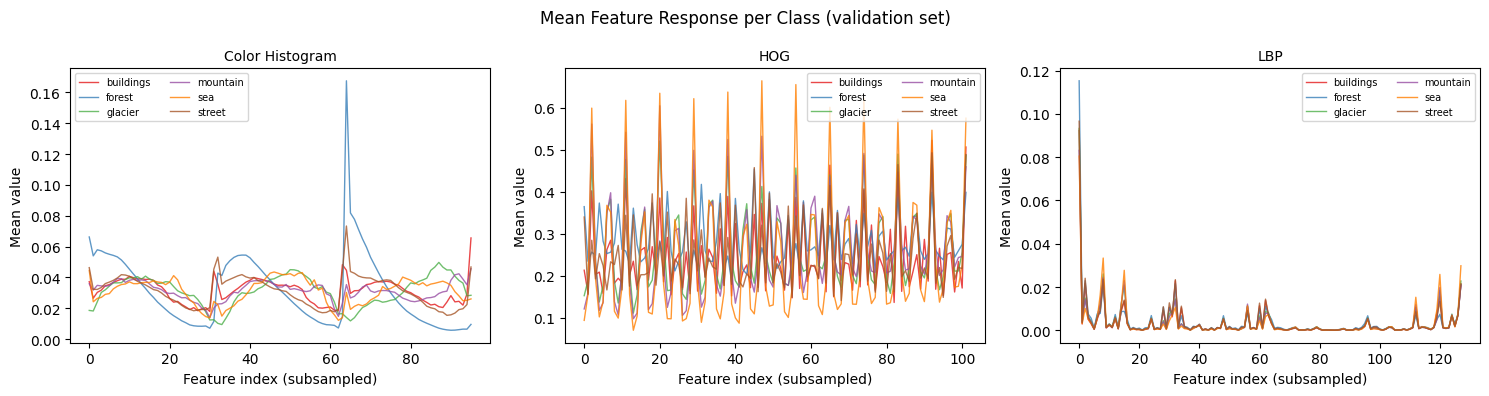

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Mean Feature Response per Class (validation set)', fontsize=12)

families = [
    ('Color Histogram',  registry['color_hist']['start'],  registry['color_hist']['end']),
    ('HOG',              registry['hog']['start'],          registry['hog']['end']),
    ('LBP',              registry['lbp']['start'],          registry['lbp']['end']),
]

for ax, (name, s, e) in zip(axes, families):
    # Subsample HOG/LBP dims for readability
    max_dims = 100
    step = max(1, (e - s) // max_dims)
    dims = np.arange(s, e, step)

    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mask = y_val == cls_idx
        mean_vec = X_val[mask][:, dims].mean(axis=0)
        ax.plot(mean_vec, label=cls_name, color=COLORS[cls_idx], alpha=0.8, linewidth=1)

    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Feature index (subsampled)')
    ax.set_ylabel('Mean value')
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(FEATURES_DIR, 'feature_distributions.png'), dpi=120, bbox_inches='tight')
plt.show()

## 4. Run MRMR — select top K features

In [11]:
# Install if needed
# import subprocess; subprocess.run(['pip', 'install', 'mrmr-selection', 'pandas'], check=True)

K = 200   # tune this — 200 is a good starting point

selected_indices = run_and_save(
    K=K,
    features_dir=FEATURES_DIR,
    verbose=True,
)

print(f'\nSelected {len(selected_indices)} feature indices')
print(f'First 20: {selected_indices[:20]}')

Running MRMR: selecting top 200 from 2384 features using 16800 training samples...


100%|██████████| 200/200 [02:06<00:00,  1.59it/s]


  Selected 200 features.
  Index range: 31 – 2382
  [train]  (16800, 2384) → (16800, 200)  saved → d:\Senior2\Vision\Project\features\train_mrmr.npz
  [val]  (900, 2384) → (900, 200)  saved → d:\Senior2\Vision\Project\features\val_mrmr.npz
  [test]  (900, 2384) → (900, 200)  saved → d:\Senior2\Vision\Project\features\test_mrmr.npz
  MRMR indices saved → d:\Senior2\Vision\Project\features\mrmr_indices.npy

Selected 200 feature indices
First 20: [2379 2138   95 2315 2134 2192 2326 2319 2313 2307 2183 2236 2132   66
 2187 2196 2186 2267 2283 2259]


## 5. Which families survived MRMR?

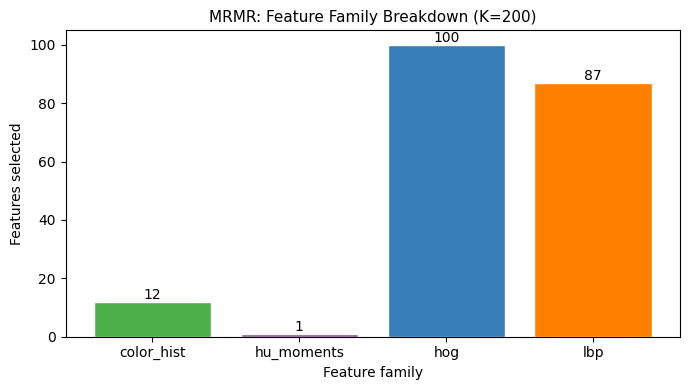


Breakdown: {'color_hist': np.int64(12), 'hu_moments': np.int64(1), 'hog': np.int64(100), 'lbp': np.int64(87)}


In [12]:
family_counts = {}
for key in ('color_hist', 'hu_moments', 'hog', 'lbp'):
    s, e = registry[key]['start'], registry[key]['end']
    count = np.sum((selected_indices >= s) & (selected_indices < e))
    family_counts[key] = count

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(family_counts.keys(), family_counts.values(),
              color=['#4daf4a','#984ea3','#377eb8','#ff7f00'], edgecolor='white')
ax.set_title(f'MRMR: Feature Family Breakdown (K={K})', fontsize=11)
ax.set_ylabel('Features selected')
ax.set_xlabel('Feature family')
for bar, val in zip(bars, family_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FEATURES_DIR, 'mrmr_family_breakdown.png'), dpi=120, bbox_inches='tight')
plt.show()
print('\nBreakdown:', family_counts)

## 6. Before vs After MRMR — feature matrix shape summary

In [13]:
print('Feature matrix shapes — before and after MRMR selection')
print('-' * 50)
for split in ('train', 'val', 'test'):
    raw  = np.load(os.path.join(FEATURES_DIR, f'{split}_features.npz'))
    sel  = np.load(os.path.join(FEATURES_DIR, f'{split}_mrmr.npz'))
    print(f'  {split:5s}  before: {raw["X"].shape}   after: {sel["X"].shape}')

Feature matrix shapes — before and after MRMR selection
--------------------------------------------------
  train  before: (16800, 2384)   after: (16800, 200)
  val    before: (900, 2384)   after: (900, 200)
  test   before: (900, 2384)   after: (900, 200)
